In [44]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [45]:
fear_greed=pd.read_csv(r"C:\phone\Desktop\Trader_Sentiment_Analysis\datasets\fear_greed_index.csv")
historical=pd.read_csv(r"C:\phone\Desktop\Trader_Sentiment_Analysis\datasets\historical_data.csv")

In [46]:
fear_greed.head()
fear_greed.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,28-04-2025
2640,1745904600,60,Greed,29-04-2025
2641,1745991000,56,Greed,30-04-2025
2642,1746077400,53,Neutral,01-05-2025
2643,1746163800,67,Greed,02-05-2025


In [47]:
historical.head()
historical.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [48]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [49]:
historical.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [50]:
fear_greed.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [51]:
historical.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [52]:
fear_greed['date']=pd.to_datetime(fear_greed['date'],
dayfirst=True).dt.date

In [53]:
historical['date'] = pd.to_datetime(
    historical['Timestamp IST'],
    dayfirst=True
).dt.date

In [54]:
fear_greed['date'].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [55]:
merged=pd.merge(fear_greed,historical,on='date',how='inner')
merged.head()

,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
1,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
2,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
3,1701754200,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,05-12-2023 03:11,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,1.700000e+12
4,1701754200,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,05-12-2023 03:11,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14,1.700000e+12


In [56]:
merged.size

4224360

In [57]:
merged['win']=merged['Closed PnL']>0
print(merged['win'])

0         False
1         False
2         False
3         False
4         False
          ...  
211213    False
211214    False
211215    False
211216    False
211217    False
Name: win, Length: 211218, dtype: bool


In [58]:
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [59]:
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [60]:
merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [61]:
merged.groupby(['classification','Direction']).size()

classification  Direction                
Extreme Fear    Buy                            807
                Close Long                    6241
                Close Short                   3117
                Long > Short                     5
                Open Long                     7005
                Open Short                    3174
                Sell                          1042
                Short > Long                     6
                Spot Dust Conversion             3
Extreme Greed   Buy                           5132
                Close Long                    7186
                Close Short                   6497
                Long > Short                     7
                Open Long                     6300
                Open Short                    7663
                Sell                          7164
                Short > Long                    11
                Spot Dust Conversion            32
Fear            Buy                     

In [62]:
merged.isnull().sum()

timestamp           0
value               0
classification      0
date                0
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
win                 0
dtype: int64

In [63]:
merged.duplicated().sum()

np.int64(0)

In [64]:
merged=merged.drop_duplicates()

In [65]:
merged.groupby('Coin')['Closed PnL'].mean()

Coin
@1        14.610183
@10       -0.015871
@100       6.906785
@103       5.508291
@107      92.821850
            ...    
kBONK     21.585456
kFLOKI    45.926746
kNEIRO     1.063887
kPEPE     10.795952
kSHIB      7.753813
Name: Closed PnL, Length: 246, dtype: float64

In [66]:
merged.groupby('Account')['Closed PnL'].sum()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    4.788532e+04
0x271b280974205ca63b716753467d5a371de622ab   -7.043619e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   -3.120360e+04
0x39cef799f8b69da1995852eea189df24eb5cae3c    1.445692e+04
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    5.349625e+04
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    1.033437e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.

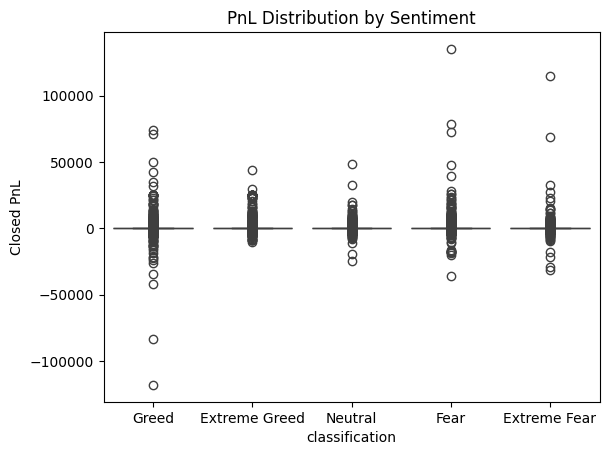

In [67]:
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution by Sentiment")
plt.show()

# PnL Distribution Analysis

**Observation:**  
The distribution of Closed PnL varied significantly across different market sentiment conditions. Greed periods generally showed higher positive returns, also contained more negative outcomes and volatility. in fear period highest outcome achieved also in extreme fear comparitively high value achieved.

**Inference:**  
Trader behavior appears strongly influenced by market sentiment. During Greed phases, traders were more confident and . During Fear phases, uncertainty and risk aversion .

**Business Impact:**  
Market sentiment can be an important indicator for risk management and trading strategy optimization. Adjusting exposure based on sentiment conditions may help improve profitability and reduce downside risk.

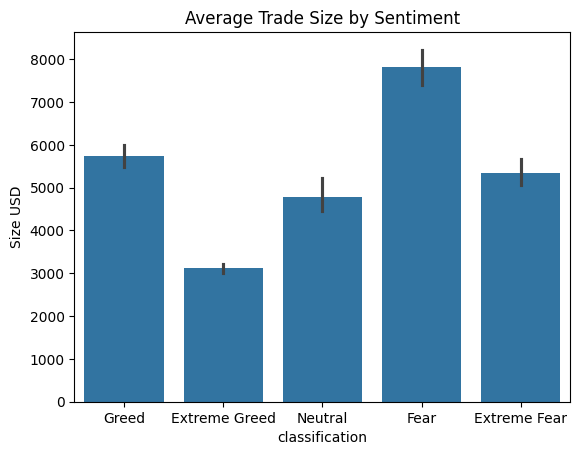

In [68]:
sns.barplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Average Trade Size by Sentiment")
plt.show()

### Trade Size Analysis

**Observation:**  
Average trade sizes differed across sentiment categories, with larger trade values observed during fear periods.

**Inference:**  
Traders appeared more aggressive and willing to commit larger capital amounts during optimistic market conditions.

**Business Impact:**  
Position sizing behavior is strongly connected to sentiment. Risk controls may be necessary during highly optimistic markets to prevent excessive exposure.

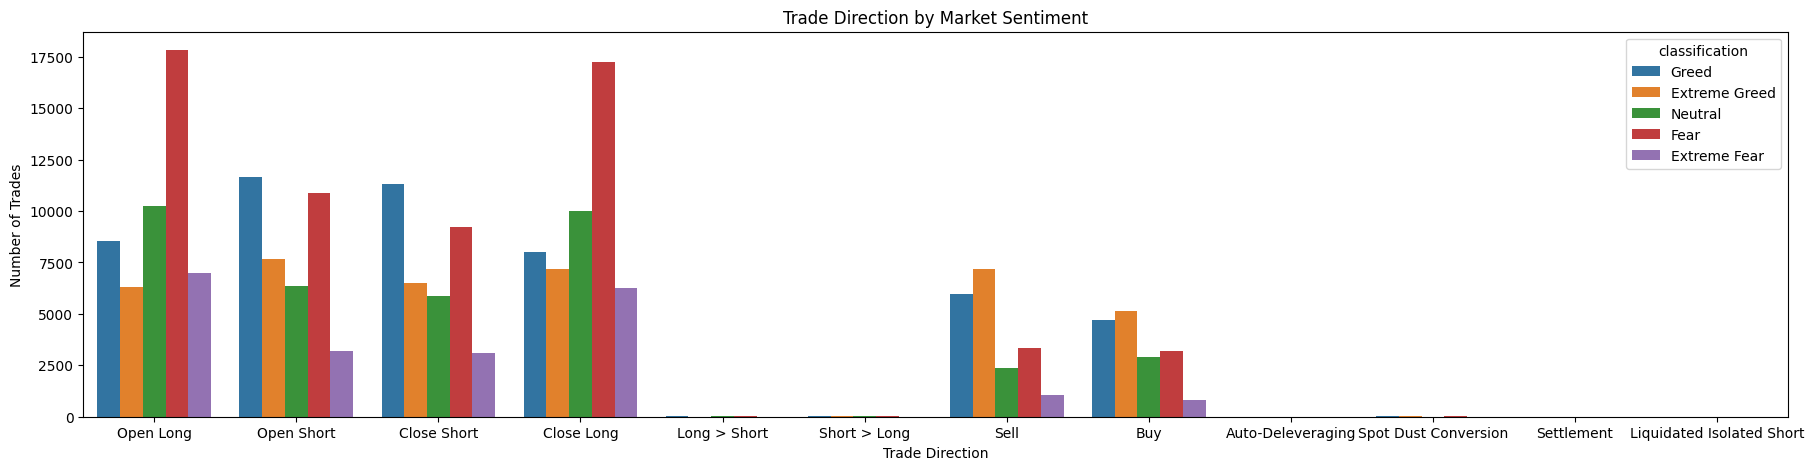

In [69]:
plt.figure(figsize=(22,5))

sns.countplot(
    x='Direction',
    hue='classification',
    data=merged
)

plt.title("Trade Direction by Market Sentiment")
plt.xlabel("Trade Direction")
plt.ylabel("Number of Trades")

plt.show()

### Trade Direction Analysis

**Observation:**  
The proportion of LONG and SHORT trades changed depending on market sentiment conditions.

**Inference:**  
Traders tended to favor LONG positions during Greed periods and SHORT or defensive positions during Fear periods.

**Business Impact:**  
Directional trading behavior reflects collective market psychology and can be used to design sentiment-aware trading strategies.

date
2023-05-01      0.000000
2023-12-05      0.000000
2023-12-14   -205.434737
2023-12-15    -24.632034
2023-12-16      0.000000
Name: Closed PnL, dtype: float64


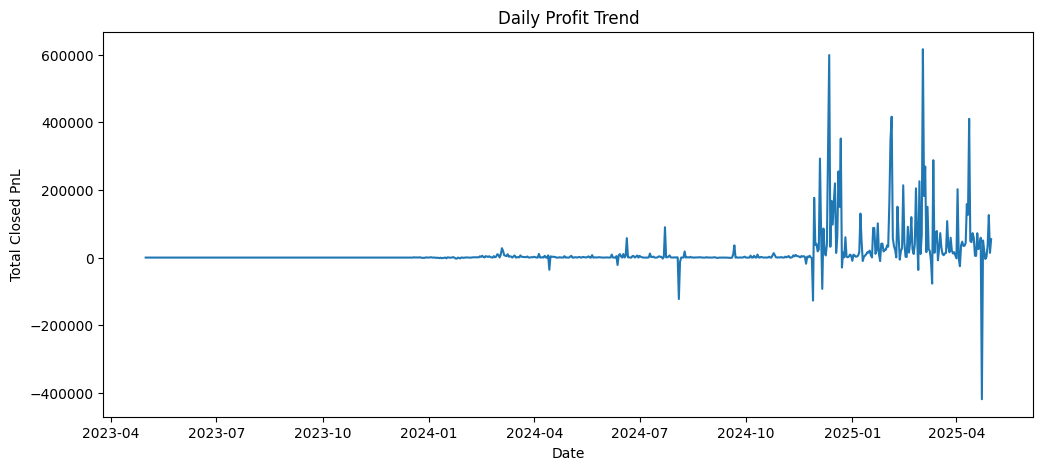

In [70]:
daily_pnl = merged.groupby('date')['Closed PnL'].sum()

print(daily_pnl.head())

plt.figure(figsize=(12,5))

daily_pnl.plot()

plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")

plt.show()

### Daily Profit Trend Analysis

**Observation:**  
Daily trader profitability fluctuated significantly over time, with periods of strong gains and substantial losses.

**Inference:**  
Trading outcomes were highly sensitive to market volatility and changing sentiment conditions.

**Business Impact:**  
Consistent risk management and adaptive trading strategies are necessary to handle volatile market environments effectively.

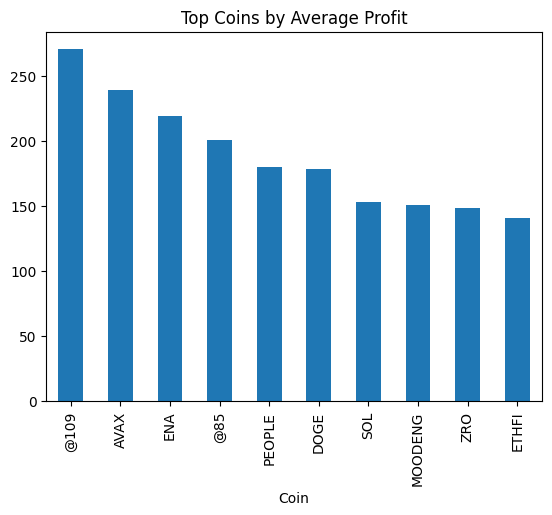

In [71]:
top_coins = merged.groupby('Coin')['Closed PnL'].mean().sort_values(ascending=False).head(10)

top_coins.plot(kind='bar')

plt.title("Top Coins by Average Profit")
plt.show()

### Coin-wise Performance Analysis

**Observation:**  
Certain cryptocurrencies generated significantly higher average profits compared to others.

**Inference:**  
Trader performance varied across assets, suggesting that some coins provided more favorable trading opportunities during the analyzed period.

**Business Impact:**  
Asset selection plays a critical role in trading profitability. Identifying historically strong-performing assets may improve portfolio performance.